# TASK 3: Multi-Class Image Classification using Convolutional Neural Network (CNN)

## Objective

The objective of this project is to build a Convolutional Neural Network (CNN) capable of classifying images into multiple categories using raw pixel values. The model is implemented using TensorFlow and Keras on the CIFAR-10 dataset.

## Dataset

The CIFAR-10 dataset consists of 60,000 color images belonging to 10 different classes.

Classes:
- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

The dataset is divided into:
- 50,000 training images
- 10,000 testing images

## Workflow

1. Import libraries
2. Load dataset
3. Preprocess images
4. Perform data augmentation
5. Build CNN model
6. Train model
7. Evaluate performance
8. Visualize results
9. Generate predictions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Loading the Dataset

The CIFAR-10 dataset is loaded directly from TensorFlow. Images are normalized so pixel values fall between 0 and 1.

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


# Visualizing Sample Images

The following images are randomly selected from the training dataset.

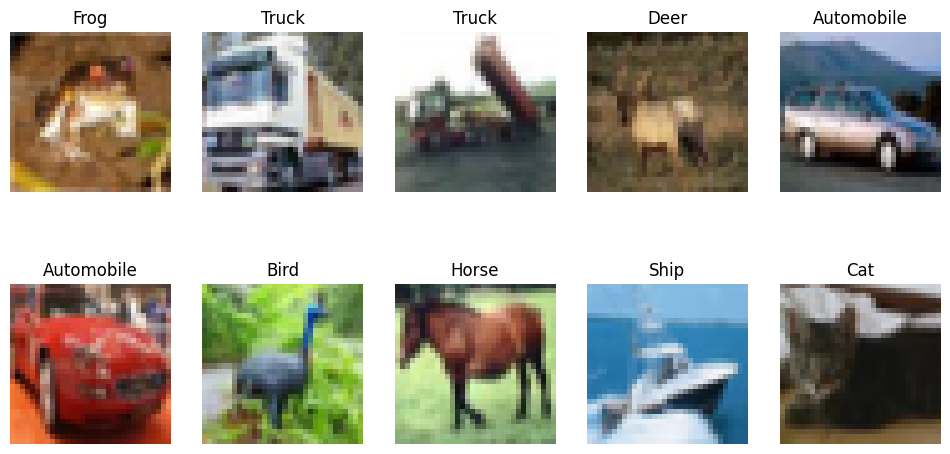

In [ ]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

# Data Augmentation

Data augmentation increases dataset diversity by applying random transformations during training.

Transformations include:

- Rotation
- Width shifting
- Height shifting
- Horizontal flipping
- Zooming

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(x_train)

# Building the CNN Model

The architecture consists of multiple convolutional layers followed by pooling layers, batch normalization, dropout, and fully connected dense layers.

In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Conv2D(32,(3,3),activation="relu"))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.30))

model.add(Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.40))

model.add(Flatten())

model.add(Dense(256,activation="relu"))
model.add(Dropout(0.50))

model.add(Dense(10,activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,802 (1.61 MB)

 Trainable params: 421,354 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

# Training the CNN

The model is trained using augmented images for 20 epochs while monitoring validation performance.

In [ ]:
history = model.fit(
    datagen.flow(x_train,y_train,batch_size=64),
    epochs=20,
    validation_data=(x_test,y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 59ms/step - accuracy: 0.3036 - loss: 1.8923 - val_accuracy: 0.3781 - val_loss: 1.8675
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.4386 - loss: 1.5551 - val_accuracy: 0.4202 - val_loss: 1.7503
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.5002 - loss: 1.4085 - val_accuracy: 0.5087 - val_loss: 1.3659
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.5404 - loss: 1.3014 - val_accuracy: 0.6077 - val_loss: 1.1117
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.5765 - loss: 1.2146 - val_accuracy: 0.4694 - val_loss: 1.7075
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.6008 - loss: 1.1489 - val_accuracy: 0.6466 - val_loss: 1.0022
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.6231 - loss: 1.0959 - val_accuracy: 0.5623 - val_loss: 1.4110
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.6386 - loss: 1.0529 - 

# Model Evaluation

The trained model is evaluated using the testing dataset.

In [ ]:
loss, accuracy = model.evaluate(x_test,y_test)

print("Test Loss:",loss)
print("Test Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7283 - loss: 0.8040
Test Loss: 0.804017961025238
Test Accuracy: 0.7282999753952026


# Training and Validation Accuracy

The graph below illustrates training accuracy and validation accuracy throughout the learning process.

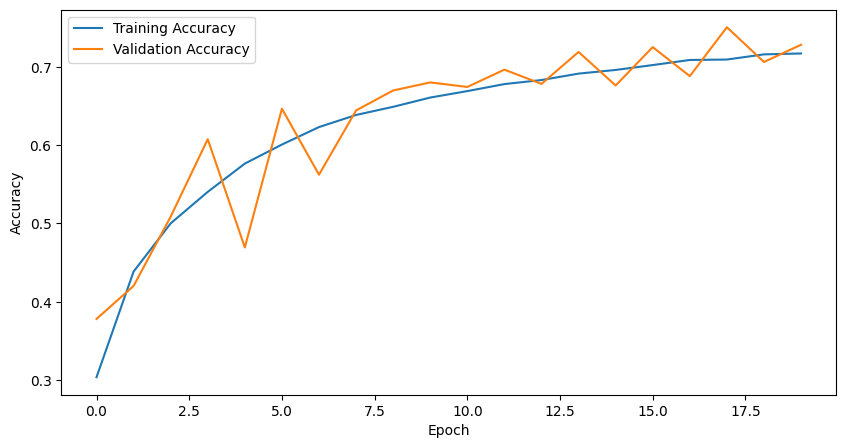

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Confusion Matrix

The confusion matrix summarizes the classification performance across all classes.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


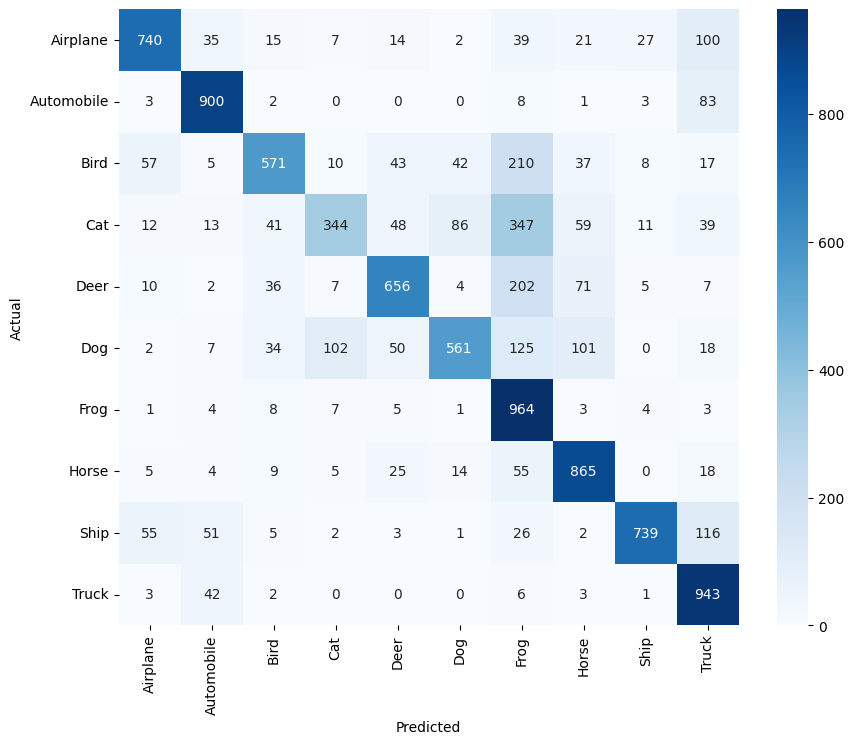

In [ ]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions,axis=1)

cm = confusion_matrix(y_test,predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification Report

Precision, recall, and F1-score are computed for every class.

In [ ]:
print(classification_report(
    y_test,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.83      0.74      0.78      1000
  Automobile       0.85      0.90      0.87      1000
        Bird       0.79      0.57      0.66      1000
         Cat       0.71      0.34      0.46      1000
        Deer       0.78      0.66      0.71      1000
         Dog       0.79      0.56      0.66      1000
        Frog       0.49      0.96      0.65      1000
       Horse       0.74      0.86      0.80      1000
        Ship       0.93      0.74      0.82      1000
       Truck       0.70      0.94      0.80      1000

    accuracy                           0.73     10000
   macro avg       0.76      0.73      0.72     10000
weighted avg       0.76      0.73      0.72     10000



# Sample Predictions

The following images demonstrate predictions generated by the trained CNN model.

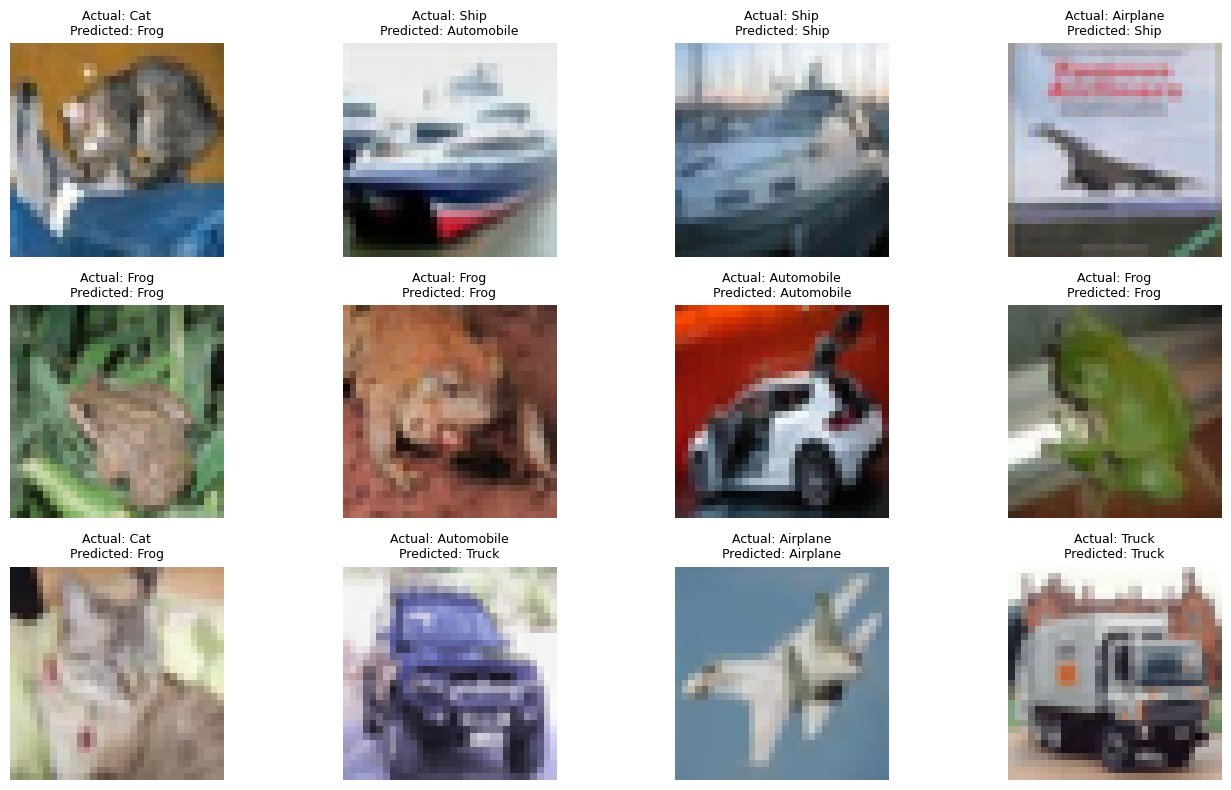

In [ ]:
plt.figure(figsize=(14,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[i])
    plt.title(
        "Actual: {}\nPredicted: {}".format(
            class_names[y_test[i][0]],
            class_names[predicted_classes[i]]
        ),
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()

plt.show()

# Conclusion

A Convolutional Neural Network (CNN) was successfully implemented using TensorFlow and Keras for multi-class image classification on the CIFAR-10 dataset.

The project included:

- Image preprocessing
- Data augmentation
- Multi-layer CNN architecture
- Model training
- Performance evaluation
- Accuracy and loss visualization
- Confusion matrix
- Classification report
- Sample predictions

The use of convolutional layers enabled the model to automatically learn spatial features from images, while data augmentation and dropout helped improve generalization and reduce overfitting.